In [7]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import math

In [8]:

V_lung = 3000.0   # mL  (adult male respiratory volume)

# Bacterial growth 
u = 0.057 # h-1
o = 10e3 # input of volume of microaspirations 1/ml/h 

#o IS A PLACEHOLDER FOR MICROASPIRATION COEFFICIENT *  BACTERIAL DENSITY IN THE NASAL PHARYNX AT ONE TIME. 

K_max    = 1e6  # CFU/mL  carrying capacity 
r_growth = 0.057  # h^-1    growth rate
B0_init = 1.6e6 * .01    # CFU/mL  #initial bacterial population at t=0, #PLACEHOLDER (need to make 3 days with immune response hitting carrying capacity)
l = 0 #ANTIOBIOTIC PLACEHOLDER #killing rate due to antibiotics

c = [u, K_max, o, l] # constants vector (recommended format by Prof. Kim)

# Mucociliary clearance (gamma)
# The 55%/80min transport velocity maps to ~0.02 h^-1 effective rate.
# Asthmatic: ~40% reduction in beat frequency → 0.012 h^-1.
gamma_h = 0.02    # h^-1  healthy
gamma_a = 0.012   # h^-1  asthmatic

# Mucus Volume (Mv) 
# dMv/dt = sigma_basal + sigma_infection * B/(Kmp+B) - gamma * Mv
sigma_basal = 0.5    # mL/h  basal mucus production (same for both)
sigma_infect = 2.0   # mL/h  extra mucus during infection
Kmp = 1e6            # CFU/mL  half-sat for infection-driven mucus
Mv0_h = sigma_basal / gamma_h   # ~25 mL  steady-state before infection
Mv0_a = sigma_basal / gamma_a   # ~42 mL  (asthmatic has more baseline mucus)

# Alveolar Macrophages (MA) 
# dMA/dt = sigma_ma*(MA0-MA) - sigma_death_MA - sigma_usedup * K_MA * MA * B/(Km+B)
MA0 = 14e9    # cells  (literature: healthy adult baseline)
Km  = 5e6     # CFU/mL  half-saturation constant for phagocytic killing

sigma_ma = 0.02       # h^-1  rate of recruitment back toward MA0
sigma_death_MA_h = 0.0046 * V_lung   # cells/h (literature)
sigma_death_MA_a = 0.0056 * V_lung   # cells/h (literature)

# K_MA [per cell per h]
# kill_MA = K_MA * MA * B/(Km+B)
# At B=1e5, K_MA_h*MA0*(1e5/(5e6+1e5)) > r*1e5 → K_MA_h > ~1.2e-5
K_MA_h = 1.7e-5   # per cell per h (healthy)
K_MA_a = 8.5e-6   # per cell per h (asthmatic, ~50% reduced)
sigma_usedup_MA = 0.01   # fraction of phagocytic events that consume a macrophage

# Neutrophils (N)
# dN/dt = S_N*C*(1-N/Nmax) - delta_N*N - sigma_usedup_N * K_N * N * B/(Km+B)
N_max = 8e9    # cells ( ~2661 cells/µL × 3000 mL × 1000 µL/mL)
N_50  = 190.8 * 1000 * V_lung   # ~5.7e8 cells  (half-sat for cytokine recruitment)

delta_N_h = 1.0 / 12.0   # h^-1  lifespan ~12 h (healthy)
delta_N_a = 1.0 / 48.0   # h^-1  lifespan ~48 h (asthmatic)

# K_N [per cell per h]: neutrophils provide secondary killing once recruited at high B
K_N_h = 3.6e-4   # per cell per h (healthy)
K_N_a = 0.8e-4   # per cell per h (asthmatic, ~78% reduced)
sigma_usedup_N = 0.001

r_N_max = 5e4 * V_lung   # cells/h  max neutrophil recruitment flux

# Cytokine (quasi-steady-state)
C0_h = 0.1;  C0_a = 0.3   # basal cytokine (higher in asthma = chronic inflammation)
alpha_cyt  = 2.0
B_half_cyt = 1e7
C_half     = 1.0

# --- Amoxicillin PK (mirrored from PBL_1_amoxicillin.ipynb) ---
_F = 0.85; _alpha_pk = 1.02; _w_pk = 0.66; _beta_pk = 0.92; _gamma_pk = 1.99
_Vg = 0.44; _Vb = 17.23; _Vl_pk = 2.53  # L

def _f_pk(t, y):
    ag, ab, al = y
    dose = 500 if int(t) % 8 == 0 else 0  # 500 mg oral every 8 h
    return [
        dose/_Vg - _alpha_pk*ag,
        _F*_alpha_pk*ag*(_Vg/_Vb) - _w_pk*ab - _beta_pk*ab + _gamma_pk*al*(_Vl_pk/_Vb),
        _beta_pk*ab*(_Vb/_Vl_pk) - _gamma_pk*al
    ]

_pk = solve_ivp(_f_pk, [0, 168], [0, 0, 0],
                t_eval=np.linspace(0, 168, 5000), method='RK45', rtol=1e-8, atol=1e-11)

# --- Amoxicillin PD: Hill/Emax model ---
# l(t) = k_max_amx * C_lung(t) / (EC50_amx + C_lung(t))
k_max_amx = 2.0   # h^-1  max kill rate vs. S. pneumoniae (PLACEHOLDER)
EC50_amx  = 0.25  # mg/L  half-max effective lung concentration (PLACEHOLDER)

def l_amx(t):
    """Time-varying amoxicillin kill rate (h^-1) via Hill/Emax PD model."""
    C = max(float(np.interp(t, _pk.t, _pk.y[2])), 0.0)
    return k_max_amx * C / (EC50_amx + C)


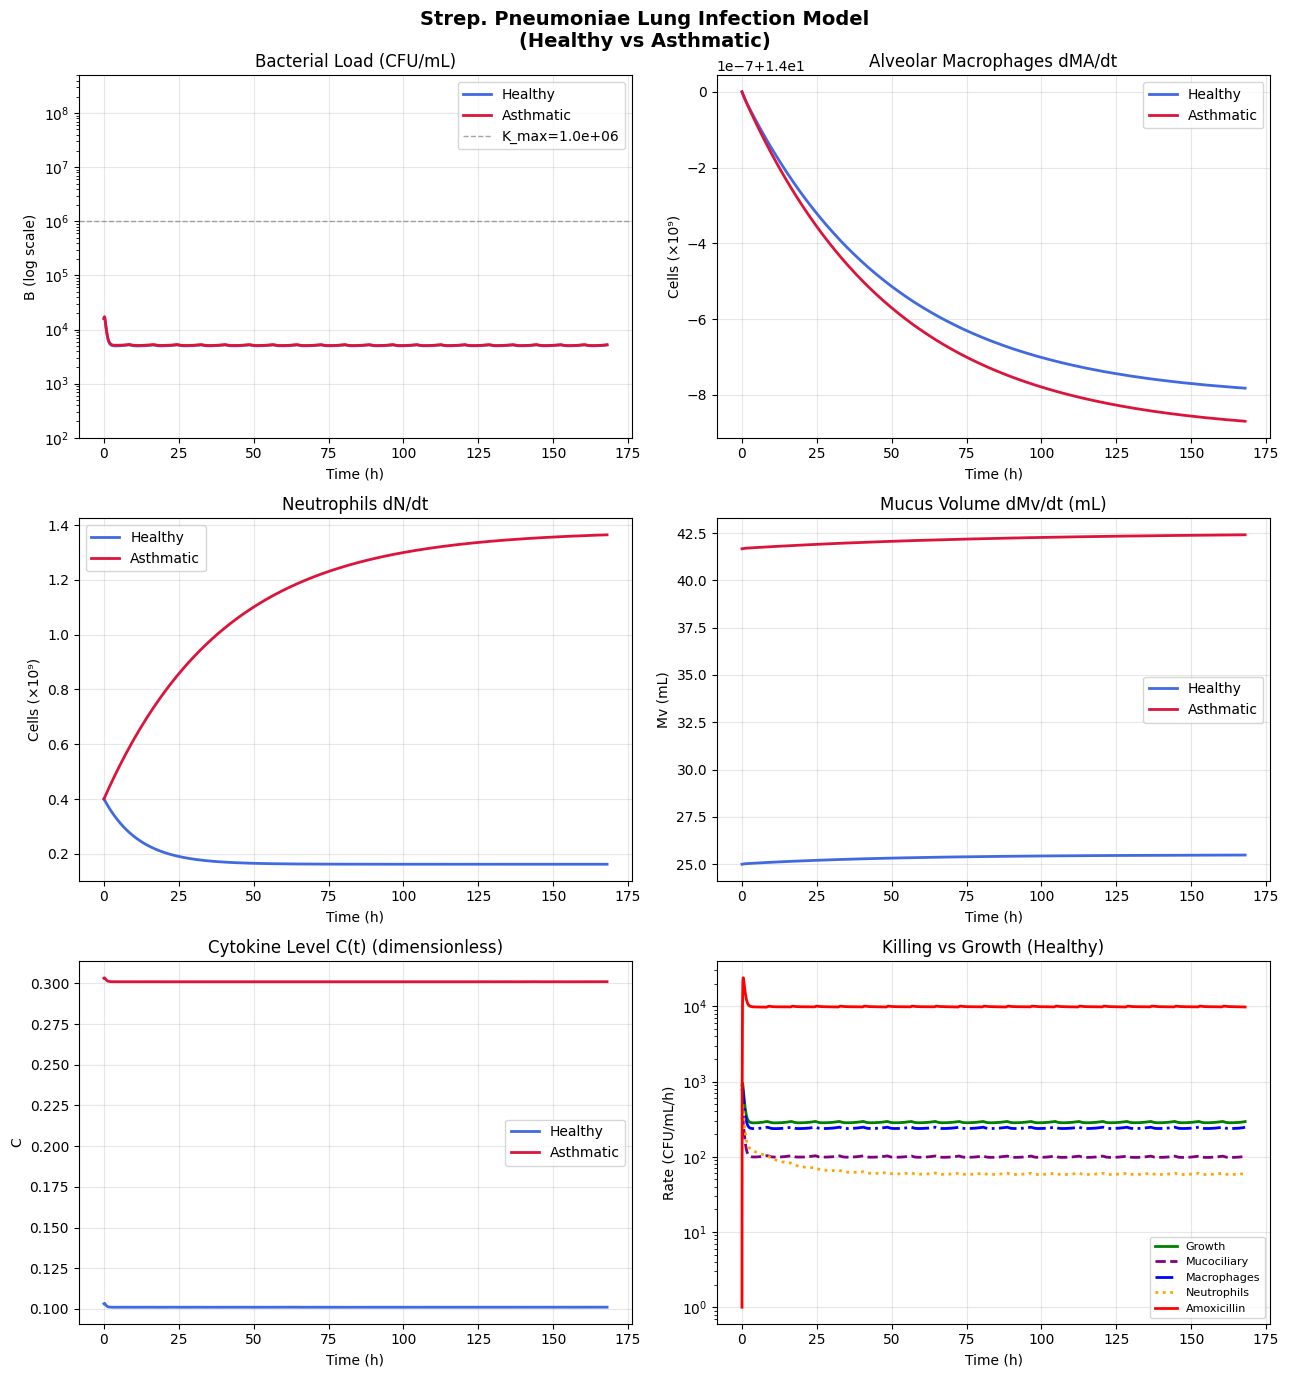

In [9]:

def cytokine(B, C0):
    return C0 + alpha_cyt * B / (B + B_half_cyt)

def odes(t, y, p):
    
    B, MA, N, Mv = y
    (gamma, sigma_ma_p, sigma_death_MA, K_MA, delta_N, K_N, C0) = p

    B  = max(B,  0.0)
    MA = max(MA, 0.0)
    N  = max(N,  0.0)
    Mv = max(Mv, 1e-6)

    C = cytokine(B, C0)
    
    #Bacterial Growth over time
    # dB/dt: Input - mucociliary - macrophage killing - neutrophil killing - antibiotic killing
    growth     = c[0] * B * (1 - (B/c[1])) + c[2] 
    
    # Mucociliary clearance: impaired when Mv > Mv_ref (excess mucus traps cilia)
    Mv_ref     = sigma_basal / gamma
    muco_clear = gamma * B * (Mv_ref / Mv)
    kill_MA    = K_MA * MA * B / (Km + B)   # K_MA·MA·BL/(Km+BL)
    kill_N     = K_N  * N  * B / (Km + B)   # K_N·N·BL/(Km+BL)
    dBNdt = growth - muco_clear - kill_MA - kill_N - (l_amx(t) * B)

    # dMA/dt: Recruitment to baseline - death - consumed by killing ---
    recruit_MA  = sigma_ma_p * (MA0 - MA)
    consumed_MA = sigma_usedup_MA * K_MA * MA * B / (Km + B)
    dMAdt = recruit_MA - sigma_death_MA - consumed_MA

    # dN/dt: Cytokine-driven recruitment - death - consumed by killing ---
    S_N        = r_N_max * C / (C + C_half) * max(0.0, 1.0 - N / N_max)
    death_N    = delta_N * N
    consumed_N = sigma_usedup_N * K_N * N * B / (Km + B)
    dNdt = S_N - death_N - consumed_N

    # dMv/dt: Basal + infection-driven production - cilia clearance ---
    prod_Mv  = sigma_basal + sigma_infect * B / (Kmp + B)
    clear_Mv = gamma * Mv
    dMvdt = prod_Mv - clear_Mv

    return [dBNdt, dMAdt, dNdt, dMvdt]

N0_init = 0.05 * N_max

p_h = (gamma_h, sigma_ma, sigma_death_MA_h, K_MA_h, delta_N_h, K_N_h, C0_h)
p_a = (gamma_a, sigma_ma, sigma_death_MA_a, K_MA_a, delta_N_a, K_N_a, C0_a)

y0_h = [B0_init, MA0, N0_init, Mv0_h]
y0_a = [B0_init, MA0, N0_init, Mv0_a]

tspan = np.linspace(0, 168, 3000)

sol_h = solve_ivp(lambda t, y: odes(t, y, p_h), [tspan[0], tspan[-1]], y0_h,
                  t_eval=tspan, method='RK45', rtol=1e-7, atol=1e-10)
sol_a = solve_ivp(lambda t, y: odes(t, y, p_a), [tspan[0], tspan[-1]], y0_a,
                  t_eval=tspan, method='RK45', rtol=1e-7, atol=1e-10)

C_h_ts = [cytokine(b, C0_h) for b in sol_h.y[0]]
C_a_ts = [cytokine(b, C0_a) for b in sol_a.y[0]]

#Plot
fig, axes = plt.subplots(3, 2, figsize=(13, 14))
fig.suptitle('Strep. Pneumoniae Lung Infection Model\n(Healthy vs Asthmatic)',
             fontsize=14, fontweight='bold')

kw_h = dict(color='royalblue', lw=2, label='Healthy')
kw_a = dict(color='crimson',   lw=2, label='Asthmatic')

# Bacteria
ax = axes[0, 0]
ax.plot(sol_h.t, sol_h.y[0], **kw_h)
ax.plot(sol_a.t, sol_a.y[0], **kw_a)
ax.axhline(K_max, ls='--', color='grey', lw=1, alpha=0.7, label=f'K_max={K_max:.1e}')
ax.set_yscale('log'); ax.set_ylim(1e2, 5e8)
ax.set_title('Bacterial Load (CFU/mL)'); ax.set_ylabel('B (log scale)')
ax.set_xlabel('Time (h)'); ax.legend(); ax.grid(True, alpha=0.3)

# Alveolar Macrophages
ax = axes[0, 1]
ax.plot(sol_h.t, sol_h.y[1] / 1e9, **kw_h)
ax.plot(sol_a.t, sol_a.y[1] / 1e9, **kw_a)
ax.set_title('Alveolar Macrophages dMA/dt')
ax.set_ylabel('Cells (×10⁹)'); ax.set_xlabel('Time (h)')
ax.legend(); ax.grid(True, alpha=0.3)

# Neutrophils
ax = axes[1, 0]
ax.plot(sol_h.t, sol_h.y[2] / 1e9, **kw_h)
ax.plot(sol_a.t, sol_a.y[2] / 1e9, **kw_a)
ax.set_title('Neutrophils dN/dt')
ax.set_ylabel('Cells (×10⁹)'); ax.set_xlabel('Time (h)')
ax.legend(); ax.grid(True, alpha=0.3)

# Mucus Volume
ax = axes[1, 1]
ax.plot(sol_h.t, sol_h.y[3], **kw_h)
ax.plot(sol_a.t, sol_a.y[3], **kw_a)
ax.set_title('Mucus Volume dMv/dt (mL)')
ax.set_ylabel('Mv (mL)'); ax.set_xlabel('Time (h)')
ax.legend(); ax.grid(True, alpha=0.3)

# Cytokine
ax = axes[2, 0]
ax.plot(sol_h.t, C_h_ts, **kw_h)
ax.plot(sol_a.t, C_a_ts, **kw_a)
ax.set_title('Cytokine Level C(t) (dimensionless)')
ax.set_ylabel('C'); ax.set_xlabel('Time (h)')
ax.legend(); ax.grid(True, alpha=0.3)

# Killing vs Growth breakdown (healthy)
ax = axes[2, 1]
B_h = sol_h.y[0]; MA_h = sol_h.y[1]; N_h = sol_h.y[2]; Mv_h = sol_h.y[3]
Mv_ref_h  = sigma_basal / gamma_h
Mv_h_safe = np.maximum(Mv_h, 1e-6)
k_muco = gamma_h * B_h * (Mv_ref_h / Mv_h_safe)
k_mac  = K_MA_h * MA_h * B_h / (Km + B_h)
k_neut = K_N_h  * N_h  * B_h / (Km + B_h)
k_abx  = np.array([l_amx(t) for t in sol_h.t]) * B_h
g_h    = r_growth * B_h * (1 - B_h / K_max)
ax.plot(sol_h.t, np.maximum(g_h,    1), color='green',  lw=2, ls='-',  label='Growth')
ax.plot(sol_h.t, np.maximum(k_muco, 1), color='purple', lw=2, ls='--', label='Mucociliary')
ax.plot(sol_h.t, np.maximum(k_mac,  1), color='blue',   lw=2, ls='-.', label='Macrophages')
ax.plot(sol_h.t, np.maximum(k_neut, 1), color='orange', lw=2, ls=':',  label='Neutrophils')
ax.plot(sol_h.t, np.maximum(k_abx,  1), color='red',    lw=2, ls='-',  label='Amoxicillin')
ax.set_yscale('log')
ax.set_title('Killing vs Growth (Healthy)')
ax.set_ylabel('Rate (CFU/mL/h)'); ax.set_xlabel('Time (h)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Imports

In [10]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Constants

In [11]:

V_lung = 3000.0   # mL  (adult male respiratory volume)

# Bacterial growth 
u = 0.057 # h-1
o = 10e3 # input of volume of microaspirations 1/ml/h 

#o IS A PLACEHOLDER FOR MICROASPIRATION COEFFICIENT *  BACTERIAL DENSITY IN THE NASAL PHARYNX AT ONE TIME. 

K_max    = 2.3e8  # CFU/mL  carrying capacity (literature)
r_growth = 0.057  # h^-1    growth rate in epithelial lining fluid (literature)
B0_init  = 0    # CFU/mL  the lungs start with no s. pneumoniae as they must migrate from the nasal passages 
l = 0  # ANTIBIOTIC PLACEHOLDER - killing rate due to antibiotics

c = [u, K_max, o, l] # constants vector (recommended format by Prof. Kim)

# Mucociliary clearance (gamma)
# The 55%/80min transport velocity maps to ~0.02 h^-1 effective rate.
# Asthmatic: ~40% reduction in beat frequency → 0.012 h^-1.
gamma_h = 0.02    # h^-1  healthy
gamma_a = 0.012   # h^-1  asthmatic

# Mucus Volume (Mv) 
# dMv/dt = sigma_basal + sigma_infection * B/(Kmp+B) - gamma * Mv
sigma_basal = 0.5    # mL/h  basal mucus production (same for both)
sigma_infect = 2.0   # mL/h  extra mucus during infection
Kmp = 1e6            # CFU/mL  half-sat for infection-driven mucus
Mv0_h = sigma_basal / gamma_h   # ~25 mL  steady-state before infection
Mv0_a = sigma_basal / gamma_a   # ~42 mL  (asthmatic has more baseline mucus)

# Alveolar Macrophages (MA) 
# dMA/dt = sigma_ma*(MA0-MA) - sigma_death_MA - sigma_usedup * K_MA * MA * B/(Km+B)
MA0 = 14e9    # cells  (literature: healthy adult baseline)
Km  = 5e6     # CFU/mL  half-saturation constant for phagocytic killing

sigma_ma = 0.02       # h^-1  rate of recruitment back toward MA0
sigma_death_MA_h = 0.0046 * V_lung   # cells/h (literature)
sigma_death_MA_a = 0.0056 * V_lung   # cells/h (literature)

# K_MA [per cell per h]
# kill_MA = K_MA * MA * B/(Km+B)
# At B=1e5, K_MA_h*MA0*(1e5/(5e6+1e5)) > r*1e5 → K_MA_h > ~1.2e-5
K_MA_h = 1.7e-5   # per cell per h (healthy)
K_MA_a = 8.5e-6   # per cell per h (asthmatic, ~50% reduced)
sigma_usedup_MA = 0.01   # fraction of phagocytic events that consume a macrophage

# Neutrophils (N)
# dN/dt = S_N*C*(1-N/Nmax) - delta_N*N - sigma_usedup_N * K_N * N * B/(Km+B)
N_max = 8e9    # cells ( ~2661 cells/µL × 3000 mL × 1000 µL/mL)
N_50  = 190.8 * 1000 * V_lung   # ~5.7e8 cells  (half-sat for cytokine recruitment)

delta_N_h = 1.0 / 12.0   # h^-1  lifespan ~12 h (healthy)
delta_N_a = 1.0 / 48.0   # h^-1  lifespan ~48 h (asthmatic)

# K_N [per cell per h]: neutrophils provide secondary killing once recruited at high B
K_N_h = 3.6e-4   # per cell per h (healthy)
K_N_a = 0.8e-4   # per cell per h (asthmatic, ~78% reduced)
sigma_usedup_N = 0.001

r_N_max = 5e4 * V_lung   # cells/h  max neutrophil recruitment flux

# Cytokine (quasi-steady-state)
C0_h = 0.1;  C0_a = 0.3   # basal cytokine (higher in asthma = chronic inflammation)
alpha_cyt  = 2.0
B_half_cyt = 1e7
C_half     = 1.0

# --- Amoxicillin PK (mirrored from PBL_1_amoxicillin.ipynb) ---
_F = 0.85; _alpha_pk = 1.02; _w_pk = 0.66; _beta_pk = 0.92; _gamma_pk = 1.99
_Vg = 0.44; _Vb = 17.23; _Vl_pk = 2.53  # L

def _f_pk(t, y):
    ag, ab, al = y
    dose = 500 if int(t) % 8 == 0 else 0  # 500 mg oral every 8 h
    return [
        dose/_Vg - _alpha_pk*ag,
        _F*_alpha_pk*ag*(_Vg/_Vb) - _w_pk*ab - _beta_pk*ab + _gamma_pk*al*(_Vl_pk/_Vb),
        _beta_pk*ab*(_Vb/_Vl_pk) - _gamma_pk*al
    ]

_pk = solve_ivp(_f_pk, [0, 168], [0, 0, 0],
                t_eval=np.linspace(0, 168, 5000), method='RK45', rtol=1e-8, atol=1e-11)

# --- Amoxicillin PD: Hill/Emax model ---
# l(t) = k_max_amx * C_lung(t) / (EC50_amx + C_lung(t))
k_max_amx = 2.0   # h^-1  max kill rate vs. S. pneumoniae (PLACEHOLDER)
EC50_amx  = 0.25  # mg/L  half-max effective lung concentration (PLACEHOLDER)

def l_amx(t):
    """Time-varying amoxicillin kill rate (h^-1) via Hill/Emax PD model."""
    C = max(float(np.interp(t, _pk.t, _pk.y[2])), 0.0)
    return k_max_amx * C / (EC50_amx + C)


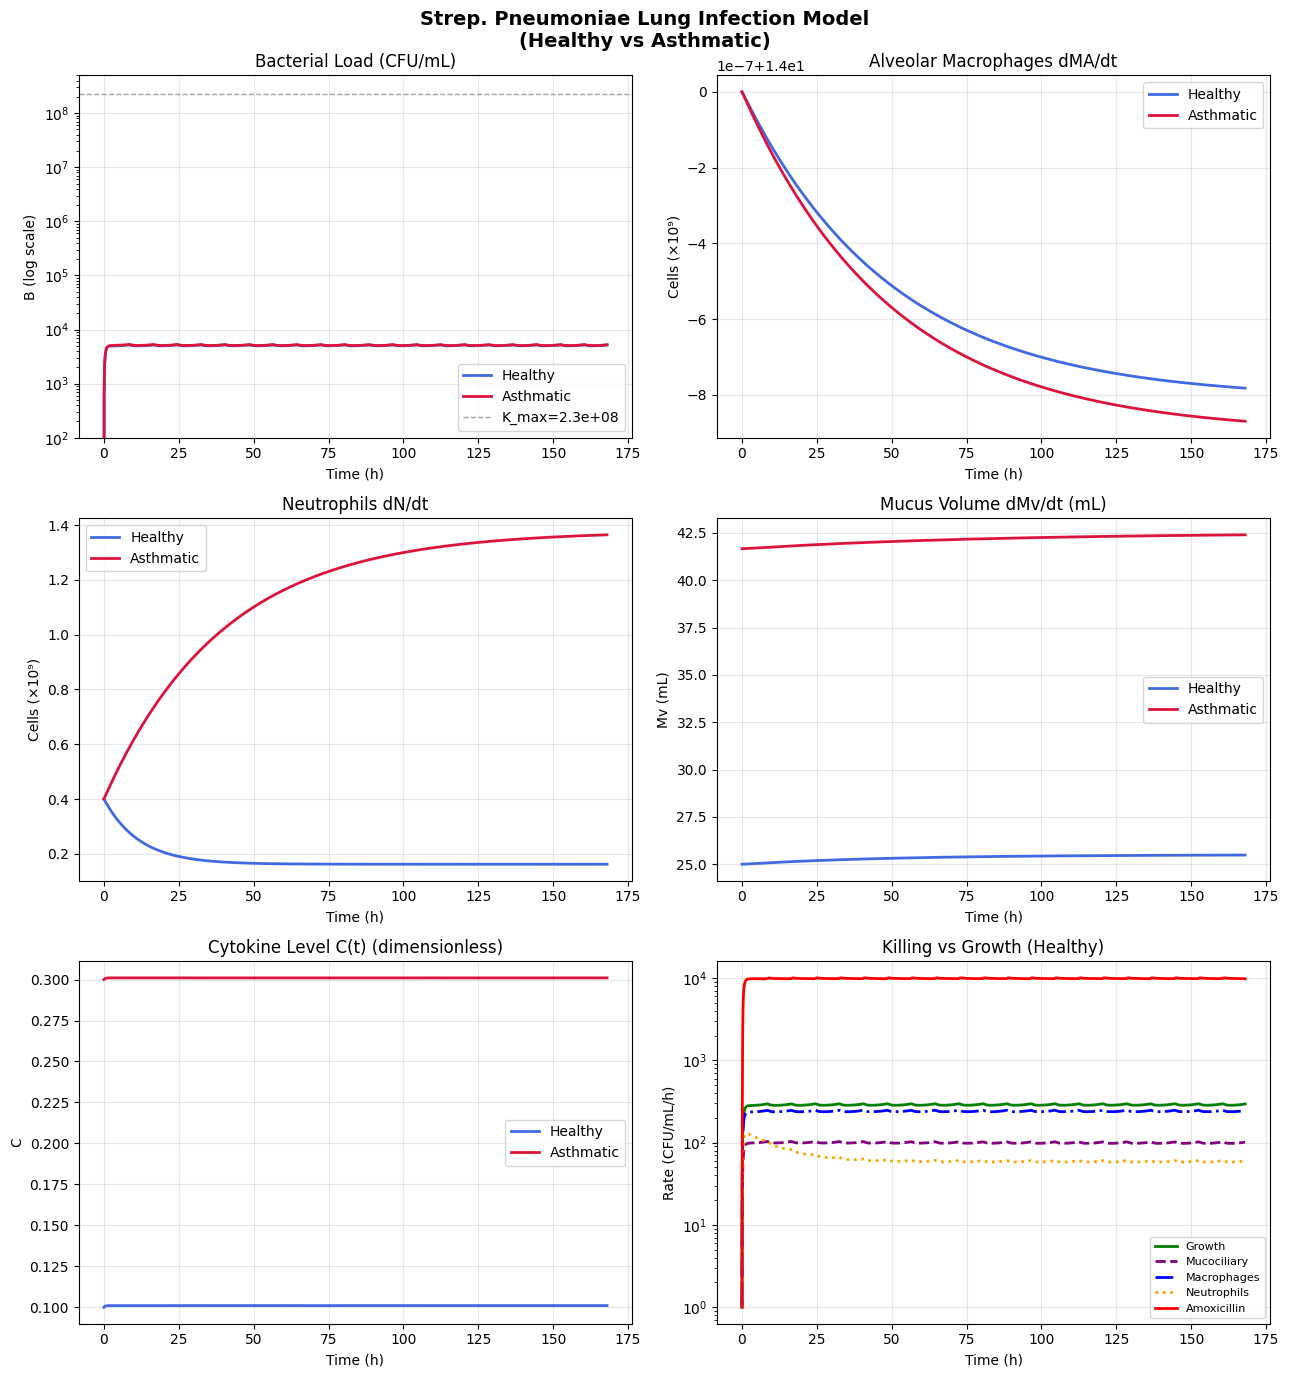

In [12]:

def cytokine(B, C0):
    return C0 + alpha_cyt * B / (B + B_half_cyt)

def odes(t, y, p):
    
    B, MA, N, Mv = y
    (gamma, sigma_ma_p, sigma_death_MA, K_MA, delta_N, K_N, C0) = p

    B  = max(B,  0.0)
    MA = max(MA, 0.0)
    N  = max(N,  0.0)
    Mv = max(Mv, 1e-6)

    C = cytokine(B, C0)
    
    #Bacterial Growth over time
    # dB/dt: Input - mucociliary - macrophage killing - neutrophil killing - antibiotic killing
    growth     = c[0] * B * (1 - (B/c[1])) + c[2] 
    
    # Mucociliary clearance: impaired when Mv > Mv_ref (excess mucus traps cilia)
    Mv_ref     = sigma_basal / gamma
    muco_clear = gamma * B * (Mv_ref / Mv)
    kill_MA    = K_MA * MA * B / (Km + B)   # K_MA·MA·BL/(Km+BL)
    kill_N     = K_N  * N  * B / (Km + B)   # K_N·N·BL/(Km+BL)
    dBdt = growth - muco_clear - kill_MA - kill_N - (l_amx(t) * B)

    # dMA/dt: Recruitment to baseline - death - consumed by killing ---
    recruit_MA  = sigma_ma_p * (MA0 - MA)
    consumed_MA = sigma_usedup_MA * K_MA * MA * B / (Km + B)
    dMAdt = recruit_MA - sigma_death_MA - consumed_MA

    # dN/dt: Cytokine-driven recruitment - death - consumed by killing ---
    S_N        = r_N_max * C / (C + C_half) * max(0.0, 1.0 - N / N_max)
    death_N    = delta_N * N
    consumed_N = sigma_usedup_N * K_N * N * B / (Km + B)
    dNdt = S_N - death_N - consumed_N

    # dMv/dt: Basal + infection-driven production - cilia clearance ---
    prod_Mv  = sigma_basal + sigma_infect * B / (Kmp + B)
    clear_Mv = gamma * Mv
    dMvdt = prod_Mv - clear_Mv

    return [dBdt, dMAdt, dNdt, dMvdt]

N0_init = 0.05 * N_max

p_h = (gamma_h, sigma_ma, sigma_death_MA_h, K_MA_h, delta_N_h, K_N_h, C0_h)
p_a = (gamma_a, sigma_ma, sigma_death_MA_a, K_MA_a, delta_N_a, K_N_a, C0_a)

y0_h = [B0_init, MA0, N0_init, Mv0_h]
y0_a = [B0_init, MA0, N0_init, Mv0_a]

tspan = np.linspace(0, 168, 3000)

sol_h = solve_ivp(lambda t, y: odes(t, y, p_h), [tspan[0], tspan[-1]], y0_h,
                  t_eval=tspan, method='RK45', rtol=1e-7, atol=1e-10)
sol_a = solve_ivp(lambda t, y: odes(t, y, p_a), [tspan[0], tspan[-1]], y0_a,
                  t_eval=tspan, method='RK45', rtol=1e-7, atol=1e-10)

C_h_ts = [cytokine(b, C0_h) for b in sol_h.y[0]]
C_a_ts = [cytokine(b, C0_a) for b in sol_a.y[0]]

#Plot
fig, axes = plt.subplots(3, 2, figsize=(13, 14))
fig.suptitle('Strep. Pneumoniae Lung Infection Model\n(Healthy vs Asthmatic)',
             fontsize=14, fontweight='bold')

kw_h = dict(color='royalblue', lw=2, label='Healthy')
kw_a = dict(color='crimson',   lw=2, label='Asthmatic')

# Bacteria
ax = axes[0, 0]
ax.plot(sol_h.t, sol_h.y[0], **kw_h)
ax.plot(sol_a.t, sol_a.y[0], **kw_a)
ax.axhline(K_max, ls='--', color='grey', lw=1, alpha=0.7, label=f'K_max={K_max:.1e}')
ax.set_yscale('log'); ax.set_ylim(1e2, 5e8)
ax.set_title('Bacterial Load (CFU/mL)'); ax.set_ylabel('B (log scale)')
ax.set_xlabel('Time (h)'); ax.legend(); ax.grid(True, alpha=0.3)

# Alveolar Macrophages
ax = axes[0, 1]
ax.plot(sol_h.t, sol_h.y[1] / 1e9, **kw_h)
ax.plot(sol_a.t, sol_a.y[1] / 1e9, **kw_a)
ax.set_title('Alveolar Macrophages dMA/dt')
ax.set_ylabel('Cells (×10⁹)'); ax.set_xlabel('Time (h)')
ax.legend(); ax.grid(True, alpha=0.3)

# Neutrophils
ax = axes[1, 0]
ax.plot(sol_h.t, sol_h.y[2] / 1e9, **kw_h)
ax.plot(sol_a.t, sol_a.y[2] / 1e9, **kw_a)
ax.set_title('Neutrophils dN/dt')
ax.set_ylabel('Cells (×10⁹)'); ax.set_xlabel('Time (h)')
ax.legend(); ax.grid(True, alpha=0.3)

# Mucus Volume
ax = axes[1, 1]
ax.plot(sol_h.t, sol_h.y[3], **kw_h)
ax.plot(sol_a.t, sol_a.y[3], **kw_a)
ax.set_title('Mucus Volume dMv/dt (mL)')
ax.set_ylabel('Mv (mL)'); ax.set_xlabel('Time (h)')
ax.legend(); ax.grid(True, alpha=0.3)

# Cytokine
ax = axes[2, 0]
ax.plot(sol_h.t, C_h_ts, **kw_h)
ax.plot(sol_a.t, C_a_ts, **kw_a)
ax.set_title('Cytokine Level C(t) (dimensionless)')
ax.set_ylabel('C'); ax.set_xlabel('Time (h)')
ax.legend(); ax.grid(True, alpha=0.3)

# Killing vs Growth breakdown (healthy)
ax = axes[2, 1]
B_h = sol_h.y[0]; MA_h = sol_h.y[1]; N_h = sol_h.y[2]; Mv_h = sol_h.y[3]
Mv_ref_h  = sigma_basal / gamma_h
Mv_h_safe = np.maximum(Mv_h, 1e-6)
k_muco = gamma_h * B_h * (Mv_ref_h / Mv_h_safe)
k_mac  = K_MA_h * MA_h * B_h / (Km + B_h)
k_neut = K_N_h  * N_h  * B_h / (Km + B_h)
k_abx  = np.array([l_amx(t) for t in sol_h.t]) * B_h
g_h    = r_growth * B_h * (1 - B_h / K_max)
ax.plot(sol_h.t, np.maximum(g_h,    1), color='green',  lw=2, ls='-',  label='Growth')
ax.plot(sol_h.t, np.maximum(k_muco, 1), color='purple', lw=2, ls='--', label='Mucociliary')
ax.plot(sol_h.t, np.maximum(k_mac,  1), color='blue',   lw=2, ls='-.', label='Macrophages')
ax.plot(sol_h.t, np.maximum(k_neut, 1), color='orange', lw=2, ls=':',  label='Neutrophils')
ax.plot(sol_h.t, np.maximum(k_abx,  1), color='red',    lw=2, ls='-',  label='Amoxicillin')
ax.set_yscale('log')
ax.set_title('Killing vs Growth (Healthy)')
ax.set_ylabel('Rate (CFU/mL/h)'); ax.set_xlabel('Time (h)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
